## Librerias

In [162]:
import warnings
warnings.filterwarnings('ignore')

# Fix for Python 3.10+ compatibility with arelle - collections ABC migration
import collections
from collections.abc import MutableSet, MutableMapping, MutableSequence, Iterable, Mapping, Sequence
collections.MutableSet = MutableSet
collections.MutableMapping = MutableMapping
collections.MutableSequence = MutableSequence
collections.Iterable = Iterable
collections.Mapping = Mapping
collections.Sequence = Sequence

# Fix for Python 3.12 compatibility - imp module was removed
import sys
import importlib.util
sys.modules['imp'] = importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arelle import Cntlr
import os

# Bancolombia

### Lectura de datos from XLBR: Superfinanciera Liabilities

In [163]:
XBRL_PATH = "Informes Bancolombia"

FINANCIAL_STATEMENTS_DICT = {
    "BANCOLOMBIA-20201231": ["0052618568_0001_000007_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01", "2020-10-01"],
    "BANCOLOMBIA-20211231": ["0052994879_0001_000007_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01", "2021-10-01"],
    "BANCOLOMBIA-20221231": ["0053352511_0001_000007_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01", "2022-10-01"],
    "BANCOLOMBIA-20231231": ["0053784673_0001_000007_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01", "2023-10-01"],
    "BANCOLOMBIA-20241231": ["0054025847_0001_000007_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01", "2024-10-01"],
    "BANCOLOMBIA-20251231": ["0054371409_0001_000007_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01", "2025-10-01"],
}

list_of_rows = []

# Iterate through the dictionary - extract Equity, ProfitLoss, and Liabilities
for key in FINANCIAL_STATEMENTS_DICT:

    
    COMPANY_FS = FINANCIAL_STATEMENTS_DICT[key][0]
    XBRL_FILE = os.path.join(XBRL_PATH, COMPANY_FS)
    
    # Import XBRL file
    xbrl = Cntlr.Cntlr().modelManager.load(XBRL_FILE)   
    
    # Extract all numeric facts into simple tuples
    facts_list = []
    for fact in xbrl.facts:
        if fact.isNumeric:
            facts_list.append((
                str(fact.concept.qname),
                fact.value,
                fact.context.id,
                fact.context.startDatetime,
                fact.context.endDatetime
            ))
    
    # Create dataframe and assign column names directly
    if len(facts_list) > 0:
        factData = pd.DataFrame(facts_list, columns=['name', 'value', 'context_id', 'startDatetime', 'endDatetime'])
        
        # Convert value to numeric
        factData['value'] = pd.to_numeric(factData['value'], errors='coerce')
        
        period_end = pd.to_datetime(FINANCIAL_STATEMENTS_DICT[key][1])
        period_start = pd.to_datetime(FINANCIAL_STATEMENTS_DICT[key][2])
        
        # Extract EQUITY (instant period)
      
        Equity = factData[(factData['name']=="ifrs:Equity") & (factData['endDatetime']==period_end)]['value'].values[0]
        
        # Extract PROFITLOSS / NET INCOME (duration period)
       
        ProfitLoss = factData[(factData['name']=="ifrs:ProfitLoss") & (factData['endDatetime']==period_end) & (factData['startDatetime']==period_start)]['value'].values[0]
        
        # Extract LIABILITIES (instant period)
        Liabilities = factData[(factData['name']=="ifrs:Liabilities") & (factData['endDatetime']==period_end)]['value'].values[0]

        # Extract LIABILITIES (instant period)
        CurrentLiabilities = factData[(factData['name']=="ifrs:DepositsFromCustomers") & (factData['endDatetime']==period_end)]['value'].values[0]

        # Create row dict and append to list
        row_dict = {
            'Date': FINANCIAL_STATEMENTS_DICT[key][1],
            'Equity': Equity,
            'ProfitLoss': ProfitLoss,
            'Liabilities': Liabilities,
            'CurrentLiabilities': CurrentLiabilities
        }
        list_of_rows.append(row_dict)
        print(f"✓ {key} extracted - Equity: {Equity:.0f}, ProfitLoss: {ProfitLoss:.0f}, Liabilities: {Liabilities:.0f}, CurrentLiabilities: {CurrentLiabilities:.0f}")

# Create final dataframe from list of dicts
data_summary_df = pd.DataFrame(list_of_rows)

print("\n" + "="*80)
print(data_summary_df)
print("="*80)
print(f"\nDatos capturados: {len(data_summary_df)} períodos")
print(f"Columnas: {list(data_summary_df.columns)}")

✓ BANCOLOMBIA-20201231 extracted - Equity: 28115211256, ProfitLoss: -249033458, Liabilities: 227453292697, CurrentLiabilities: 180820792138
✓ BANCOLOMBIA-20211231 extracted - Equity: 33925457750, ProfitLoss: 1489334931, Liabilities: 255929590555, CurrentLiabilities: 210390847338
✓ BANCOLOMBIA-20221231 extracted - Equity: 39997550366, ProfitLoss: 1666294873, Liabilities: 312817185783, CurrentLiabilities: 250992323282
✓ BANCOLOMBIA-20231231 extracted - Equity: 39049730130, ProfitLoss: 1451940818, Liabilities: 303879077262, CurrentLiabilities: 247941179474
✓ BANCOLOMBIA-20241231 extracted - Equity: 44584274767, ProfitLoss: 1699328748, Liabilities: 327631106087, CurrentLiabilities: 279059400861
✓ BANCOLOMBIA-20251231 extracted - Equity: 29080627923, ProfitLoss: 1365604945, Liabilities: 258775570686, CurrentLiabilities: 226848574041

         Date        Equity    ProfitLoss   Liabilities  CurrentLiabilities
0  2021-01-01  2.811521e+10 -2.490335e+08  2.274533e+11        1.808208e+11
1  2022

### Descarguemos precio de la acción

In [164]:
# Merge precios CIBEST con datos financieros

# Extraccion de precios historicos - CIBEST (Bancolombia)

precios_file = "Prices.xlsx"

# Read only first rows to understand structure
df_precios = pd.read_excel(precios_file, sheet_name='Prices', 
                           engine='openpyxl')
df_precios['Fecha'] = pd.to_datetime(df_precios['Fecha'])

In [165]:
Bcol = df_precios[["Fecha","CIBEST"]].copy()
Bcol['return'] = Bcol['CIBEST']/Bcol['CIBEST'].shift(1) - 1
Bcol['volatility']=Bcol['return'].rolling(window=252).std()*252**0.5
Bcol.set_index('Fecha', inplace=True)
#Volatility calculations
Bcol

,CIBEST,return,volatility
Fecha,,,
2018-01-02,29940,NaN,NaN
2018-01-03,29980,0.001336,NaN
2018-01-04,30280,0.010007,NaN
2018-01-05,30800,0.017173,NaN
2018-01-08,30800,0.000000,NaN
...,...,...,...
2026-01-29,84500,0.005234,0.305153
2026-01-30,83500,-0.011834,0.304411
2026-02-02,81700,-0.021557,0.305301


In [166]:
# Unificación simple: Datos financieros + Precio coincidente

# Preparar datos - resetear en caso de que Date sea índice
if 'Date' not in data_summary_df.columns:
    data_summary_df = data_summary_df.reset_index()

data_summary_df['Date'] = pd.to_datetime(data_summary_df['Date'])
data_summary_df.set_index('Date', inplace=True)  # Indexar por fecha para el merge

# Merge simple: buscar coincidencia por fecha (con tolerancia de 5 días hacia atrás)
KMV_DATA = pd.merge_asof(data_summary_df, Bcol, 
                         left_index=True, 
                         right_index=True, 
                         tolerance=pd.Timedelta('5D'),
                         direction='backward')

# Restaurar Date como columna y renombrar CIBEST a Price
KMV_DATA['Date'] = KMV_DATA.index
KMV_DATA = KMV_DATA.reset_index(drop=True)

# Renombrar columna CIBEST a Price para uniforme con resto del código
KMV_DATA = KMV_DATA.rename(columns={'CIBEST': 'Price'})

### KMV MODEL - CÁLCULO DE PROBABILIDAD DE DEFAUT


In [167]:
KMV_DATA

,Equity,ProfitLoss,Liabilities,CurrentLiabilities,Price,return,volatility,Date
0,2.811521e+10,-2.490335e+08,2.274533e+11,1.808208e+11,34980,0.0,0.577208,2021-01-01
1,3.392546e+10,1.489335e+09,2.559296e+11,2.103908e+11,34700,0.0,0.288899,2022-01-01
2,3.999755e+10,1.666295e+09,3.128172e+11,2.509923e+11,42500,0.0,0.414035,2023-01-01
3,3.904973e+10,1.451941e+09,3.038791e+11,2.479412e+11,33200,0.0,0.374264,2024-01-01
4,4.458427e+10,1.699329e+09,3.276311e+11,2.790594e+11,37600,0.0,0.249242,2025-01-01
5,2.908063e+10,1.365605e+09,2.587756e+11,2.268486e+11,69200,0.0,0.296899,2026-01-01


In [168]:
# Preparación de datos KMV

# Número de acciones en circulación de Bancolombia
shares_outstanding = 964827000  # Aciones en circulación

# Preparar datos para el iterador KMV
KMV_DATA['Market_Cap'] = KMV_DATA['Price'] * shares_outstanding
KMV_DATA['Liabilities_Current'] = KMV_DATA['CurrentLiabilities'] 
KMV_DATA['Liabilities_NonCurrent'] = KMV_DATA['Liabilities'] - KMV_DATA['CurrentLiabilities']

# Default Point = Pasivos Corrientes + 0.5 * Pasivos No Corrientes
KMV_DATA['Default_Point'] = KMV_DATA['Liabilities_Current'] + 0.5 * KMV_DATA['Liabilities_NonCurrent']


In [169]:
## Sección 2: Algoritmo iterativo para calcular Asset Value y Asset Volatility

# Importar funciones necesarias para el cálculo KMV
from scipy.stats import norm, t as t_dist
from scipy.optimize import root

# Algoritmo KMV - Iteración Merton Model

kmv_results = pd.DataFrame()

for i in range(len(KMV_DATA)):
    
    # Datos del período
    equity_vol = KMV_DATA['volatility'].iloc[i]
    market_cap = KMV_DATA['Market_Cap'].iloc[i]
    liabilities_current = KMV_DATA['Liabilities_Current'].iloc[i]
    liabilities_noncurrent = KMV_DATA['Liabilities_NonCurrent'].iloc[i]
    date = KMV_DATA['Date'].iloc[i]
    

    # Inicialización
    initial_assets = market_cap + liabilities_current + liabilities_noncurrent
    assets = initial_assets
    liabilities = liabilities_current + liabilities_noncurrent
    dp = liabilities_current + 0.5 * liabilities_noncurrent  # Default Point
    initial_asset_vol = equity_vol
    asset_vol = initial_asset_vol
    equity = market_cap
    
    # Parámetros del modelo
    r = 0.05  # Risk-free rate
    T = 1     # Time horizon (1 year)
    epsilon = 1  # Inicializar convergencia
    iterations = 0
    max_iterations = 1000
    
    # Ecuaciones Merton Model
    def function1(x):
        d1 = (np.log(x/dp) + (r + 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
        d2 = (np.log(x/dp) + (r - 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
        return x - (market_cap + np.exp(-r*T)*dp*norm.cdf(d2))
    
    def function2(x):
        d1 = (np.log(assets/dp) + (r + 0.5*x**2)*T) / (x*T**0.5)
        return equity_vol - norm.cdf(d1) * (assets/market_cap) * x
    
    # Iteración hasta convergencia
    while epsilon > 0.00001 and iterations < max_iterations:
        # Resolver para asset_vol
        try:
            sol2 = root(function2, asset_vol, method='hybr')
            asset_vol_new = sol2.x[0]
        except:
            asset_vol_new = asset_vol
        
        # Resolver para assets
        try:
            sol1 = root(function1, assets, method='hybr')
            assets_new = sol1.x[0]
        except:
            assets_new = assets
        
        epsilon = abs(asset_vol_new - asset_vol)
        asset_vol = asset_vol_new
        assets = assets_new
        iterations += 1
    
    # Calcular d1 y d2 finales
    d1 = (np.log(assets/dp) + (r + 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
    d2 = (np.log(assets/dp) + (r - 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
    
    # Probabilidad de default usando t-student (como en KMV_MODEL_HISTORIC)
    default_prob = t_dist.cdf(-d2, 5)  # t-student con 5 grados de libertad
    
    # Almacenar resultados
    result_row = {
        'Date': date,
    
        'Assets': assets,
        'Liabilities': liabilities,
        'Liabilities_Current': liabilities_current,
        'Liabilities_NonCurrent': liabilities_noncurrent,
        'Default_Point': dp,
        'Market_Cap': market_cap,
        'Equity_Vol': equity_vol,
        'Asset_Vol': asset_vol,
        'd1': d1,
        'd2': d2,
        'Default_Prob': default_prob,
        'Distance_to_Default': d2,
        'Iterations': iterations
    }
    
    kmv_results = pd.concat([kmv_results, pd.DataFrame([result_row])], ignore_index=True)
    print(f"  ✓ Asset Vol: {asset_vol:.4f} | d2: {d2:.4f} | Default Prob: {default_prob*100:.4f}%")

print("\n" + "="*80)
print("✓ ITERACIÓN COMPLETADA")
print("="*80)
print(f"\nResultados: {len(kmv_results)} períodos calculados")
print("\nPrimeras filas:")
print(kmv_results[['Date', 'Assets', 'Asset_Vol', 'd2', 'Default_Prob']].head())

  ✓ Asset Vol: 0.5739 | d2: 8.7105 | Default Prob: 0.0165%
  ✓ Asset Vol: 0.2870 | d2: 17.3604 | Default Prob: 0.0006%
  ✓ Asset Vol: 0.4113 | d2: 12.0381 | Default Prob: 0.0035%
  ✓ Asset Vol: 0.3712 | d2: 12.7785 | Default Prob: 0.0026%
  ✓ Asset Vol: 0.2473 | d2: 19.4578 | Default Prob: 0.0003%
  ✓ Asset Vol: 0.2959 | d2: 19.0159 | Default Prob: 0.0004%

✓ ITERACIÓN COMPLETADA

Resultados: 6 períodos calculados

Primeras filas:
        Date        Assets  Asset_Vol         d2  Default_Prob
0 2021-01-01  3.394383e+13   0.573906   8.710459      0.000165
1 2022-01-01  3.370129e+13   0.286998  17.360353      0.000006
2 2023-01-01  4.127330e+13   0.411345  12.038084      0.000035
3 2024-01-01  3.229471e+13   0.371222  12.778541      0.000026
4 2025-01-01  3.656605e+13   0.247275  19.457799      0.000003


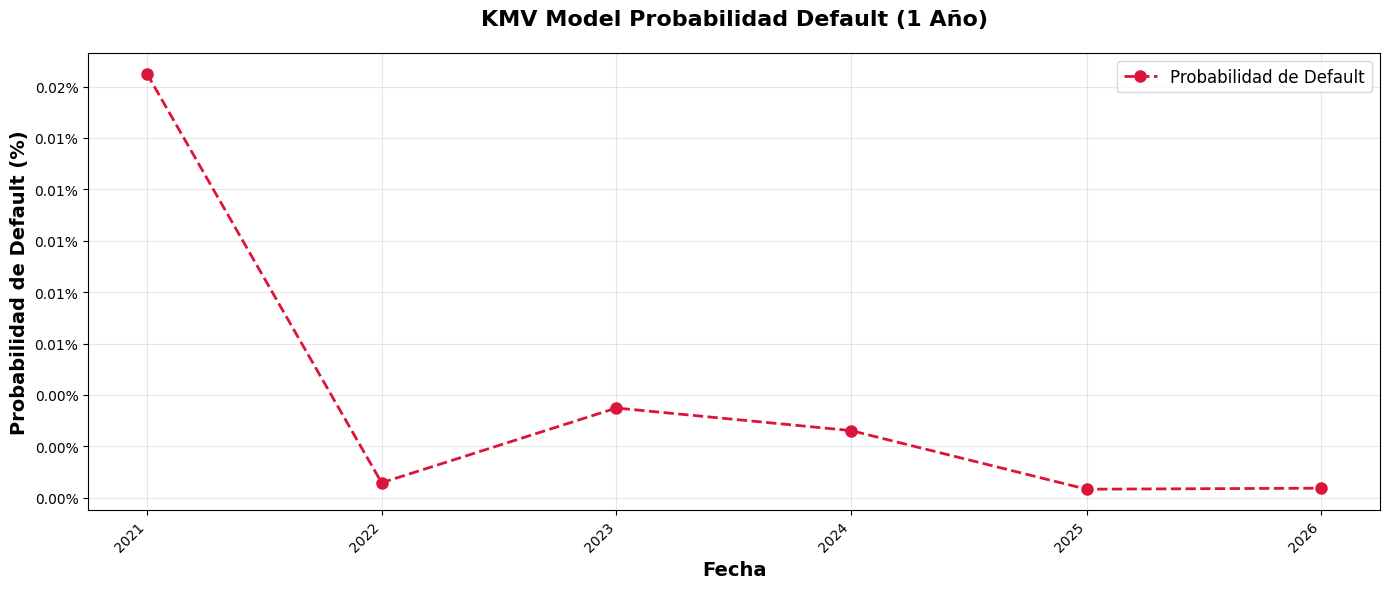

In [170]:
## Sección 3: Visualización de Resultados

# Gráfico de Probabilidad de Default
fig, ax = plt.subplots(figsize=(14, 6))

kmv_results_sorted = kmv_results.sort_values('Date')

ax.plot(kmv_results_sorted['Date'], 
        kmv_results_sorted['Default_Prob']*100, 
        marker='o', 
        linestyle='dashed', 
        color='crimson', 
        label='Probabilidad de Default', 
        markersize=8,
        linewidth=2)

ax.set_xlabel('Fecha', fontsize=14, fontweight='bold')
ax.set_ylabel('Probabilidad de Default (%)', fontsize=14, fontweight='bold')
ax.set_title('KMV Model Probabilidad Default (1 Año)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}%'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# Mineros SA

In [171]:
#Load Data from excel
ticker = "MINEROS"
sheet_name = "Mineros"

df = pd.read_excel('EEFF_Emisores_KMV.xlsx',sheet_name=sheet_name, engine='openpyxl')
df['Fecha'] = pd.to_datetime(df['Fecha'])
df.set_index('Fecha', inplace=True)

precios_file = "Prices.xlsx"

# Read only first rows to understand structure
df_precios = pd.read_excel(precios_file, sheet_name='Prices', 
                           engine='openpyxl')
df_precios['Fecha'] = pd.to_datetime(df_precios['Fecha'])

aux = df_precios[["Fecha",ticker]].copy()
aux['return'] = aux[ticker]/aux[ticker].shift(1) - 1
aux['volatility']=aux['return'].rolling(window=252).std()*252**0.5
aux.set_index('Fecha', inplace=True)
aux

,MINEROS,return,volatility
Fecha,,,
2018-01-02,2540,NaN,NaN
2018-01-03,2520,-0.007874,NaN
2018-01-04,2520,0.000000,NaN
2018-01-05,2500,-0.007937,NaN
2018-01-08,2500,0.000000,NaN
...,...,...,...
2026-01-29,21200,-0.030192,0.367057
2026-01-30,19180,-0.095283,0.380761
2026-02-02,18000,-0.061522,0.386617


In [172]:
df.sort_index(inplace=True)
df

,Pasivo,Pasivo Corriente,Patrimonio
Fecha,,,
2021-12-31,846053765,440323614,1463193642
2022-03-31,853674979,490210804,1327260120
2022-06-30,972569798,557875501,1518262860
2022-09-30,1071760667,628738315,1684223671
2022-12-31,1072626334,647357771,1666981402
2023-03-31,1097116495,702906924,1571758126
2023-06-30,1045896290,687471406,1491312701
2023-09-30,628227036,381024763,1316092835
2023-12-31,566424591,323974654,1320739677


In [173]:
# Merge simple: buscar coincidencia por fecha (con tolerancia de 5 días hacia atrás)
KMV_DATA = pd.merge_asof(df, aux, 
                         left_index=True, 
                         right_index=True, 
                         tolerance=pd.Timedelta('5D'),
                         direction='backward')

# Restaurar Fecha como columna y renombrar CIBEST a Price
KMV_DATA['Fecha'] = KMV_DATA.index
KMV_DATA = KMV_DATA.reset_index(drop=True)

# Renombrar columna CIBEST a Price para uniforme con resto del código
KMV_DATA = KMV_DATA.rename(columns={ticker: 'Price'})

In [174]:
KMV_DATA

,Pasivo,Pasivo Corriente,Patrimonio,Price,return,volatility,Fecha
0,846053765,440323614,1463193642,3635,0.000000,0.210234,2021-12-31
1,853674979,490210804,1327260120,3442,0.009384,0.201602,2022-03-31
2,972569798,557875501,1518262860,2360,0.000000,0.245374,2022-06-30
3,1071760667,628738315,1684223671,1795,0.000000,0.329948,2022-09-30
4,1072626334,647357771,1666981402,1850,0.000000,0.386622,2022-12-31
5,1097116495,702906924,1571758126,2002,0.000000,0.467489,2023-03-31
6,1045896290,687471406,1491312701,1850,0.008174,0.423217,2023-06-30
7,628227036,381024763,1316092835,1799,0.010674,0.386450,2023-09-30
8,566424591,323974654,1320739677,1835,0.000000,0.325920,2023-12-31
9,647572401,403730133,1275824294,3100,0.000000,0.305158,2024-03-30


In [175]:
# Preparación de datos KMV

# Número de acciones en circulación de Bancolombia
shares_outstanding = 295780517  # Aciones en circulación a 20/04

# Preparar datos para el iterador KMV
KMV_DATA['mkt_cap'] = KMV_DATA['Price'] * shares_outstanding
KMV_DATA['liabilities'] = KMV_DATA['Pasivo']
KMV_DATA['liabilitiescurrent'] = KMV_DATA['Pasivo Corriente'] 
KMV_DATA['liabilitiesnoncurrent'] = KMV_DATA['Pasivo'] - KMV_DATA['Pasivo Corriente'] 
KMV_DATA['Default_Point'] = KMV_DATA['liabilitiescurrent'] + 0.5 * KMV_DATA['liabilitiesnoncurrent']
KMV_DATA["date"] = KMV_DATA['Fecha']
df_final = KMV_DATA[['date','mkt_cap','volatility','liabilities','liabilitiescurrent','liabilitiesnoncurrent']]

In [176]:
#Iteration algorithm
# Importar funciones necesarias para el cálculo KMV
from scipy.stats import norm, t
company_data = pd.DataFrame().T

for i in range (0,df_final.shape[0]):
    equity_vol = df_final['volatility'].iloc[i]
    market_cap = df_final['mkt_cap'].iloc[i]
    liabilities_current = df_final['liabilitiescurrent'].iloc[i]
    liabilities_noncurrent = df_final['liabilitiesnoncurrent'].iloc[i]   
    date = df_final['date'].iloc[i]
    
    initial_assets = market_cap + liabilities_current + liabilities_noncurrent
    assets = initial_assets
    liabilities = liabilities_current + liabilities_noncurrent
    dp = liabilities_current + 0.5*liabilities_noncurrent      #default point
    initial_asset_vol = equity_vol
    asset_vol = initial_asset_vol
    equity = market_cap
    r = 0.05
    T = 1
    epsilon = 1
    
    d1 = (np.log(assets/liabilities)+(r+0.5*asset_vol**2)*T)/(asset_vol*T**0.5)
    d2 = (np.log(assets/liabilities)+(r-0.5*asset_vol**2)*T)/(asset_vol*T**0.5)
    
    def function1(x):
        return x - assets*norm.cdf(d1) + np.exp(-r*T)*norm.cdf(d2)
    
    def function2(x):
        return equity_vol - norm.cdf(d1)*(assets/equity)*x
    
    while epsilon > 0.00001:
        sol2 = root(function2,asset_vol)
        sol1 = root(function1,assets)
        
        equity = sol1.x[0]
        asset_vol_new = sol2.x[0]
        epsilon = asset_vol_new - asset_vol
        asset_vol = asset_vol_new
        
    new_list = []
    new_list.append(date)
    new_list.append(assets)
    new_list.append(liabilities)
    new_list.append(liabilities_current)
    new_list.append(liabilities_noncurrent)
    new_list.append(equity_vol)
    new_list.append(asset_vol)
    new_list.append(market_cap)
    new_list.append(d1)
    new_list.append(d2)
    new_list.append(t.cdf(-d2,5))  #t-student probability - proxy
    
    company_data = pd.concat([company_data, pd.DataFrame(new_list).T], ignore_index=True)
    
company_data = company_data.rename(columns={0:'date',
                                                1:'assets',
                                                2:'liabilities',
                                                3:'liabilities_current',
                                                4:'liabilities_noncurrent',
                                                5:'equity_vol',
                                                6:'asset_vol',
                                                7:'market_cap',
                                                8:'d1',
                                                9:'d2',
                                                10:'default_prob',                                                
                                               })

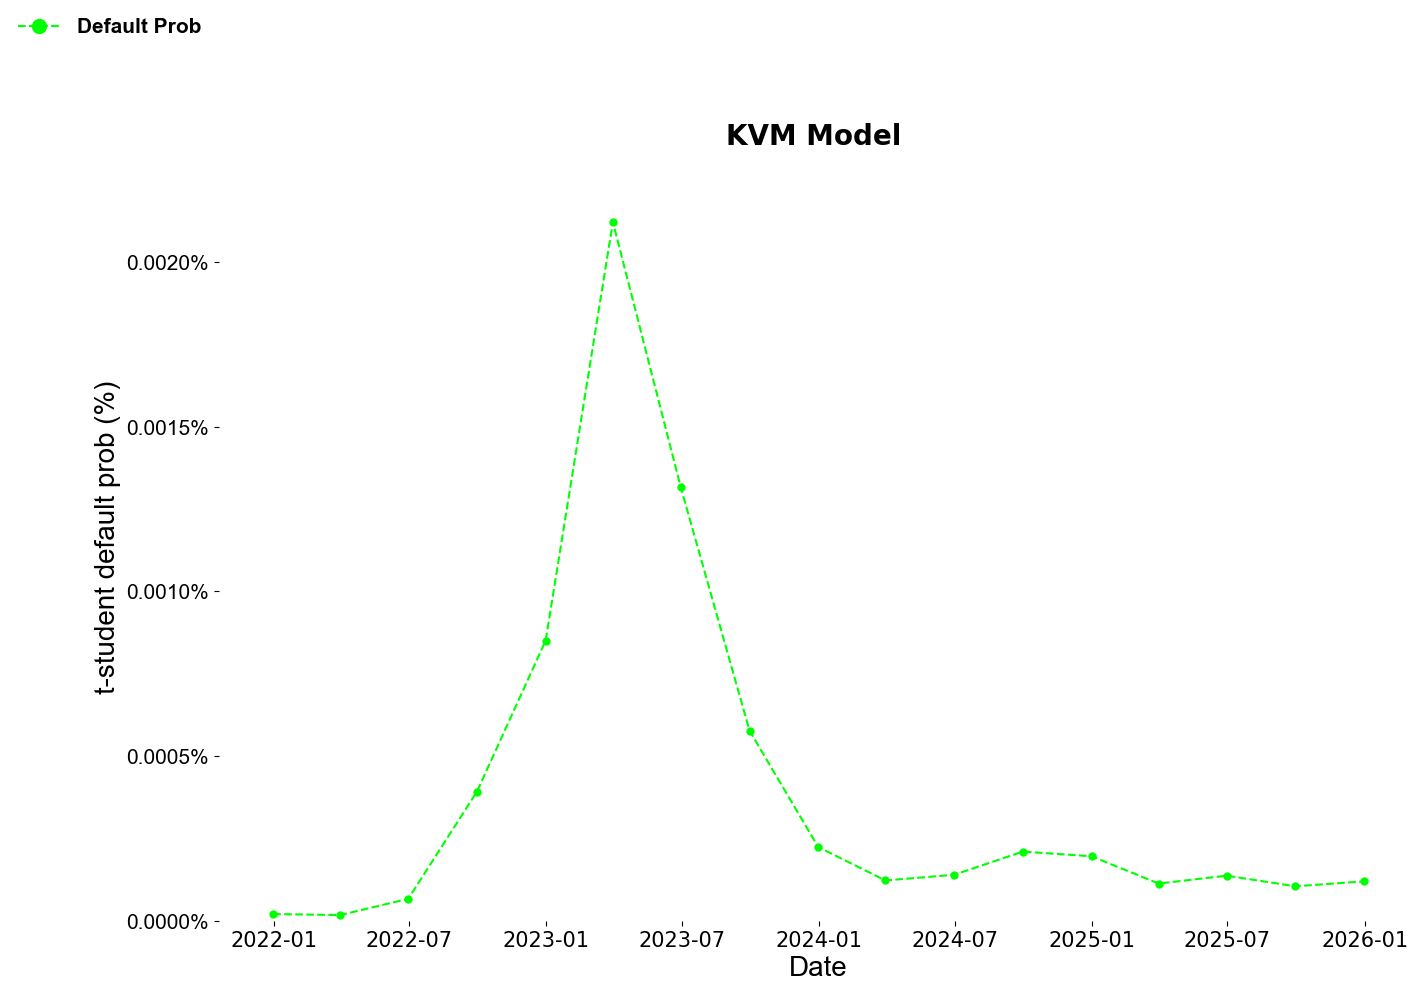

In [177]:
import matplotlib.font_manager as font_manager
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.dates as mdates
#Create chart
fig = plt.figure()
ax1 = plt.subplot(111,frameon=False)
font = font_manager.FontProperties(family='Arial',weight='bold', style='normal', size=15)

company_data.sort_values('date',ascending=True,inplace=True)

ax1.plot(company_data['date'],company_data['default_prob']*100,marker='o', linestyle='dashed',color='lime',label='Default Prob',markersize=5)
ax1.legend(frameon=False,prop=font,loc=1, bbox_to_anchor=(0.001, 1.2),ncol=10,markerscale=2)
ax1.set_xlabel('Date',fontname = "Arial", fontsize=20,color='black')
ax1.set_ylabel('t-student default prob (%)',fontname = "Arial", fontsize=20,color='black')
ax1.tick_params(axis='y', color = 'black', labelcolor='black')
ax1.yaxis.set_major_formatter(FormatStrFormatter('%2.4f%%'))
ax1.tick_params(axis="x", labelsize=15)
ax1.tick_params(axis="y", labelsize=15)

# Ajustar escala dinámicamente basada en los datos
min_val = company_data['default_prob'].min() * 100
max_val = company_data['default_prob'].max() * 100
margin = (max_val - min_val) * 0.1 if (max_val - min_val) > 0 else 0.1
ax1.set_ylim(max(0, min_val - margin), max_val + margin)

plt.title('KVM Model ',fontsize=20,weight="bold")
plt.yticks(fontname = "Arial",fontsize=15)
plt.subplots_adjust(wspace = 0.3,hspace = 0.8,bottom=0.1, right=2.0, top=1.7)
    
plt.show()

# Cemargos

In [178]:
#Load Data from excel
ticker = "CEMARGOS"
sheet_name = "Cemargos"
shares_outstanding = 1220886345  # Aciones en circulación a 20/04

df = pd.read_excel('EEFF_Emisores_KMV.xlsx',sheet_name=sheet_name, engine='openpyxl')
df['Fecha'] = pd.to_datetime(df['Fecha'])
df.set_index('Fecha', inplace=True)

precios_file = "Prices.xlsx"

# Read only first rows to understand structure
df_precios = pd.read_excel(precios_file, sheet_name='Prices', 
                           engine='openpyxl')
df_precios['Fecha'] = pd.to_datetime(df_precios['Fecha'])

aux = df_precios[["Fecha",ticker]].copy()
aux['return'] = aux[ticker]/aux[ticker].shift(1) - 1
aux['volatility']=aux['return'].rolling(window=252).std()*252**0.5
aux.set_index('Fecha', inplace=True)

df.sort_index(inplace=True)

# Merge simple: buscar coincidencia por fecha (con tolerancia de 5 días hacia atrás)
KMV_DATA = pd.merge_asof(df, aux, 
                         left_index=True, 
                         right_index=True, 
                         tolerance=pd.Timedelta('5D'),
                         direction='backward')

# Restaurar Fecha como columna y renombrar CIBEST a Price
KMV_DATA['Fecha'] = KMV_DATA.index
KMV_DATA = KMV_DATA.reset_index(drop=True)

# Renombrar columna CIBEST a Price para uniforme con resto del código
KMV_DATA = KMV_DATA.rename(columns={ticker: 'Price'})

# Preparar datos para el iterador KMV
KMV_DATA['mkt_cap'] = KMV_DATA['Price'] * shares_outstanding
KMV_DATA['liabilities'] = KMV_DATA['Pasivo']
KMV_DATA['liabilitiescurrent'] = KMV_DATA['Pasivo Corriente'] 
KMV_DATA['liabilitiesnoncurrent'] = KMV_DATA['Pasivo'] - KMV_DATA['Pasivo Corriente'] 
KMV_DATA['Default_Point'] = KMV_DATA['liabilitiescurrent'] + 0.5 * KMV_DATA['liabilitiesnoncurrent']
KMV_DATA["date"] = KMV_DATA['Fecha']
df_final = KMV_DATA[['date','mkt_cap','volatility','liabilities','liabilitiescurrent','liabilitiesnoncurrent']]

#Iteration algorithm
# Importar funciones necesarias para el cálculo KMV
from scipy.stats import norm, t
company_data = pd.DataFrame().T

for i in range (0,df_final.shape[0]):
    equity_vol = df_final['volatility'].iloc[i]
    market_cap = df_final['mkt_cap'].iloc[i]
    liabilities_current = df_final['liabilitiescurrent'].iloc[i]
    liabilities_noncurrent = df_final['liabilitiesnoncurrent'].iloc[i]   
    date = df_final['date'].iloc[i]
    
    initial_assets = market_cap + liabilities_current + liabilities_noncurrent
    assets = initial_assets
    liabilities = liabilities_current + liabilities_noncurrent
    dp = liabilities_current + 0.5*liabilities_noncurrent      #default point
    initial_asset_vol = equity_vol
    asset_vol = initial_asset_vol
    equity = market_cap
    r = 0.05
    T = 1
    epsilon = 1
    
    d1 = (np.log(assets/liabilities)+(r+0.5*asset_vol**2)*T)/(asset_vol*T**0.5)
    d2 = (np.log(assets/liabilities)+(r-0.5*asset_vol**2)*T)/(asset_vol*T**0.5)
    
    def function1(x):
        return x - assets*norm.cdf(d1) + np.exp(-r*T)*norm.cdf(d2)
    
    def function2(x):
        return equity_vol - norm.cdf(d1)*(assets/equity)*x
    
    while epsilon > 0.00001:
        sol2 = root(function2,asset_vol)
        sol1 = root(function1,assets)
        
        equity = sol1.x[0]
        asset_vol_new = sol2.x[0]
        epsilon = asset_vol_new - asset_vol
        asset_vol = asset_vol_new
        
    new_list = []
    new_list.append(date)
    new_list.append(assets)
    new_list.append(liabilities)
    new_list.append(liabilities_current)
    new_list.append(liabilities_noncurrent)
    new_list.append(equity_vol)
    new_list.append(asset_vol)
    new_list.append(market_cap)
    new_list.append(d1)
    new_list.append(d2)
    new_list.append(t.cdf(-d2,5))  #t-student probability - proxy
    
    company_data = pd.concat([company_data, pd.DataFrame(new_list).T], ignore_index=True)
    
company_data = company_data.rename(columns={0:'date',
                                                1:'assets',
                                                2:'liabilities',
                                                3:'liabilities_current',
                                                4:'liabilities_noncurrent',
                                                5:'equity_vol',
                                                6:'asset_vol',
                                                7:'market_cap',
                                                8:'d1',
                                                9:'d2',
                                                10:'default_prob',                                                
                                               })



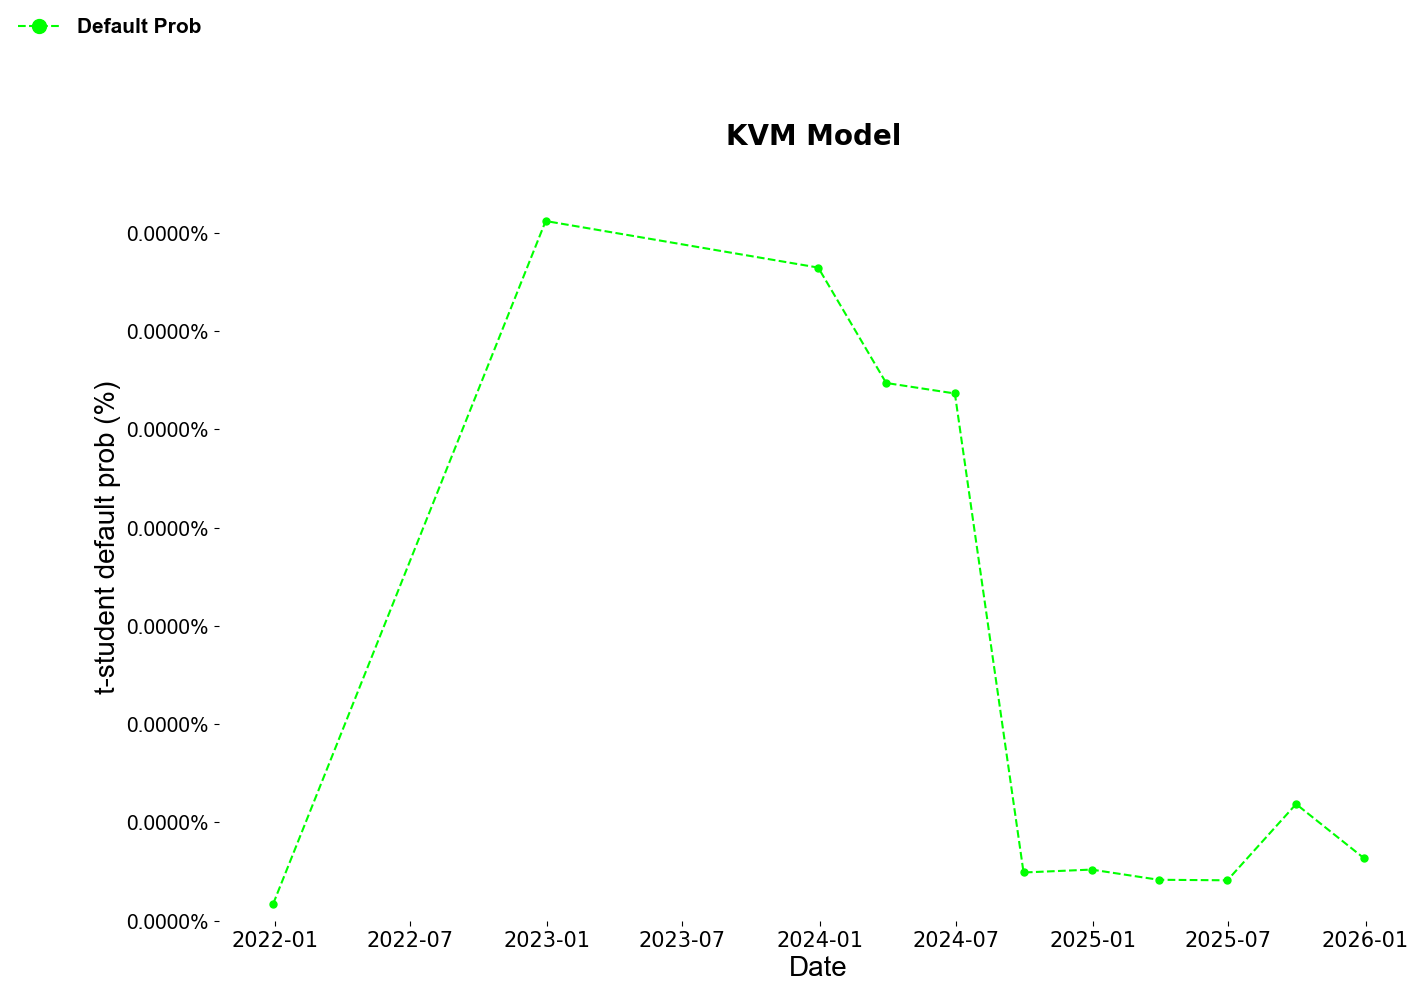

In [179]:
import matplotlib.font_manager as font_manager
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.dates as mdates
#Create chart
fig = plt.figure()
ax1 = plt.subplot(111,frameon=False)
font = font_manager.FontProperties(family='Arial',weight='bold', style='normal', size=15)

company_data.sort_values('date',ascending=True,inplace=True)

ax1.plot(company_data['date'],company_data['default_prob']*100,marker='o', linestyle='dashed',color='lime',label='Default Prob',markersize=5)
ax1.legend(frameon=False,prop=font,loc=1, bbox_to_anchor=(0.001, 1.2),ncol=10,markerscale=2)
ax1.set_xlabel('Date',fontname = "Arial", fontsize=20,color='black')
ax1.set_ylabel('t-student default prob (%)',fontname = "Arial", fontsize=20,color='black')
ax1.tick_params(axis='y', color = 'black', labelcolor='black')
ax1.yaxis.set_major_formatter(FormatStrFormatter('%2.4f%%'))
ax1.tick_params(axis="x", labelsize=15)
ax1.tick_params(axis="y", labelsize=15)

# Ajustar escala dinámicamente basada en los datos
min_val = company_data['default_prob'].min() * 100
max_val = company_data['default_prob'].max() * 100
margin = (max_val - min_val) * 0.1 if (max_val - min_val) > 0 else 0.1
ax1.set_ylim(max(0, min_val - margin), max_val + margin)

plt.title('KVM Model ',fontsize=20,weight="bold")
plt.yticks(fontname = "Arial",fontsize=15)
plt.subplots_adjust(wspace = 0.3,hspace = 0.8,bottom=0.1, right=2.0, top=1.7)
    
plt.show()

# Ecopetrol

In [180]:
#Load Data from excel
ticker = "ECOPETROL"
sheet_name = "Ecopetrol"
shares_outstanding = 41116698456  # Aciones en circulación a 20/04

df = pd.read_excel('EEFF_Emisores_KMV.xlsx',sheet_name=sheet_name, engine='openpyxl')
df['Fecha'] = pd.to_datetime(df['Fecha'])
df.set_index('Fecha', inplace=True)

precios_file = "Prices.xlsx"

# Read only first rows to understand structure
df_precios = pd.read_excel(precios_file, sheet_name='Prices', 
                           engine='openpyxl')
df_precios['Fecha'] = pd.to_datetime(df_precios['Fecha'])

aux = df_precios[["Fecha",ticker]].copy()
aux['return'] = aux[ticker]/aux[ticker].shift(1) - 1
aux['volatility']=aux['return'].rolling(window=252).std()*252**0.5
aux.set_index('Fecha', inplace=True)

df.sort_index(inplace=True)

# Merge simple: buscar coincidencia por fecha (con tolerancia de 5 días hacia atrás)
KMV_DATA = pd.merge_asof(df, aux, 
                         left_index=True, 
                         right_index=True, 
                         tolerance=pd.Timedelta('5D'),
                         direction='backward')

# Restaurar Fecha como columna y renombrar CIBEST a Price
KMV_DATA['Fecha'] = KMV_DATA.index
KMV_DATA = KMV_DATA.reset_index(drop=True)

# Renombrar columna CIBEST a Price para uniforme con resto del código
KMV_DATA = KMV_DATA.rename(columns={ticker: 'Price'})

# Preparar datos para el iterador KMV
KMV_DATA['mkt_cap'] = KMV_DATA['Price'] * shares_outstanding
KMV_DATA['liabilities'] = KMV_DATA['Pasivo']
KMV_DATA['liabilitiescurrent'] = KMV_DATA['Pasivo Corriente'] 
KMV_DATA['liabilitiesnoncurrent'] = KMV_DATA['Pasivo'] - KMV_DATA['Pasivo Corriente'] 
KMV_DATA['Default_Point'] = KMV_DATA['liabilitiescurrent'] + 0.5 * KMV_DATA['liabilitiesnoncurrent']
KMV_DATA["date"] = KMV_DATA['Fecha']
df_final = KMV_DATA[['date','mkt_cap','volatility','liabilities','liabilitiescurrent','liabilitiesnoncurrent']]

#Iteration algorithm
# Importar funciones necesarias para el cálculo KMV
from scipy.stats import norm, t
company_data = pd.DataFrame().T

for i in range (0,df_final.shape[0]):
    equity_vol = df_final['volatility'].iloc[i]
    market_cap = df_final['mkt_cap'].iloc[i]
    liabilities_current = df_final['liabilitiescurrent'].iloc[i]
    liabilities_noncurrent = df_final['liabilitiesnoncurrent'].iloc[i]   
    date = df_final['date'].iloc[i]
    
    initial_assets = market_cap + liabilities_current + liabilities_noncurrent
    assets = initial_assets
    liabilities = liabilities_current + liabilities_noncurrent
    dp = liabilities_current + 0.5*liabilities_noncurrent      #default point
    initial_asset_vol = equity_vol
    asset_vol = initial_asset_vol
    equity = market_cap
    r = 0.05
    T = 1
    epsilon = 1
    
    d1 = (np.log(assets/liabilities)+(r+0.5*asset_vol**2)*T)/(asset_vol*T**0.5)
    d2 = (np.log(assets/liabilities)+(r-0.5*asset_vol**2)*T)/(asset_vol*T**0.5)
    
    def function1(x):
        return x - assets*norm.cdf(d1) + np.exp(-r*T)*norm.cdf(d2)
    
    def function2(x):
        return equity_vol - norm.cdf(d1)*(assets/equity)*x
    
    while epsilon > 0.00001:
        sol2 = root(function2,asset_vol)
        sol1 = root(function1,assets)
        
        equity = sol1.x[0]
        asset_vol_new = sol2.x[0]
        epsilon = asset_vol_new - asset_vol
        asset_vol = asset_vol_new
        
    new_list = []
    new_list.append(date)
    new_list.append(assets)
    new_list.append(liabilities)
    new_list.append(liabilities_current)
    new_list.append(liabilities_noncurrent)
    new_list.append(equity_vol)
    new_list.append(asset_vol)
    new_list.append(market_cap)
    new_list.append(d1)
    new_list.append(d2)
    new_list.append(t.cdf(-d2,5))  #t-student probability - proxy
    
    company_data = pd.concat([company_data, pd.DataFrame(new_list).T], ignore_index=True)
    
company_data = company_data.rename(columns={0:'date',
                                                1:'assets',
                                                2:'liabilities',
                                                3:'liabilities_current',
                                                4:'liabilities_noncurrent',
                                                5:'equity_vol',
                                                6:'asset_vol',
                                                7:'market_cap',
                                                8:'d1',
                                                9:'d2',
                                                10:'default_prob',                                                
                                               })



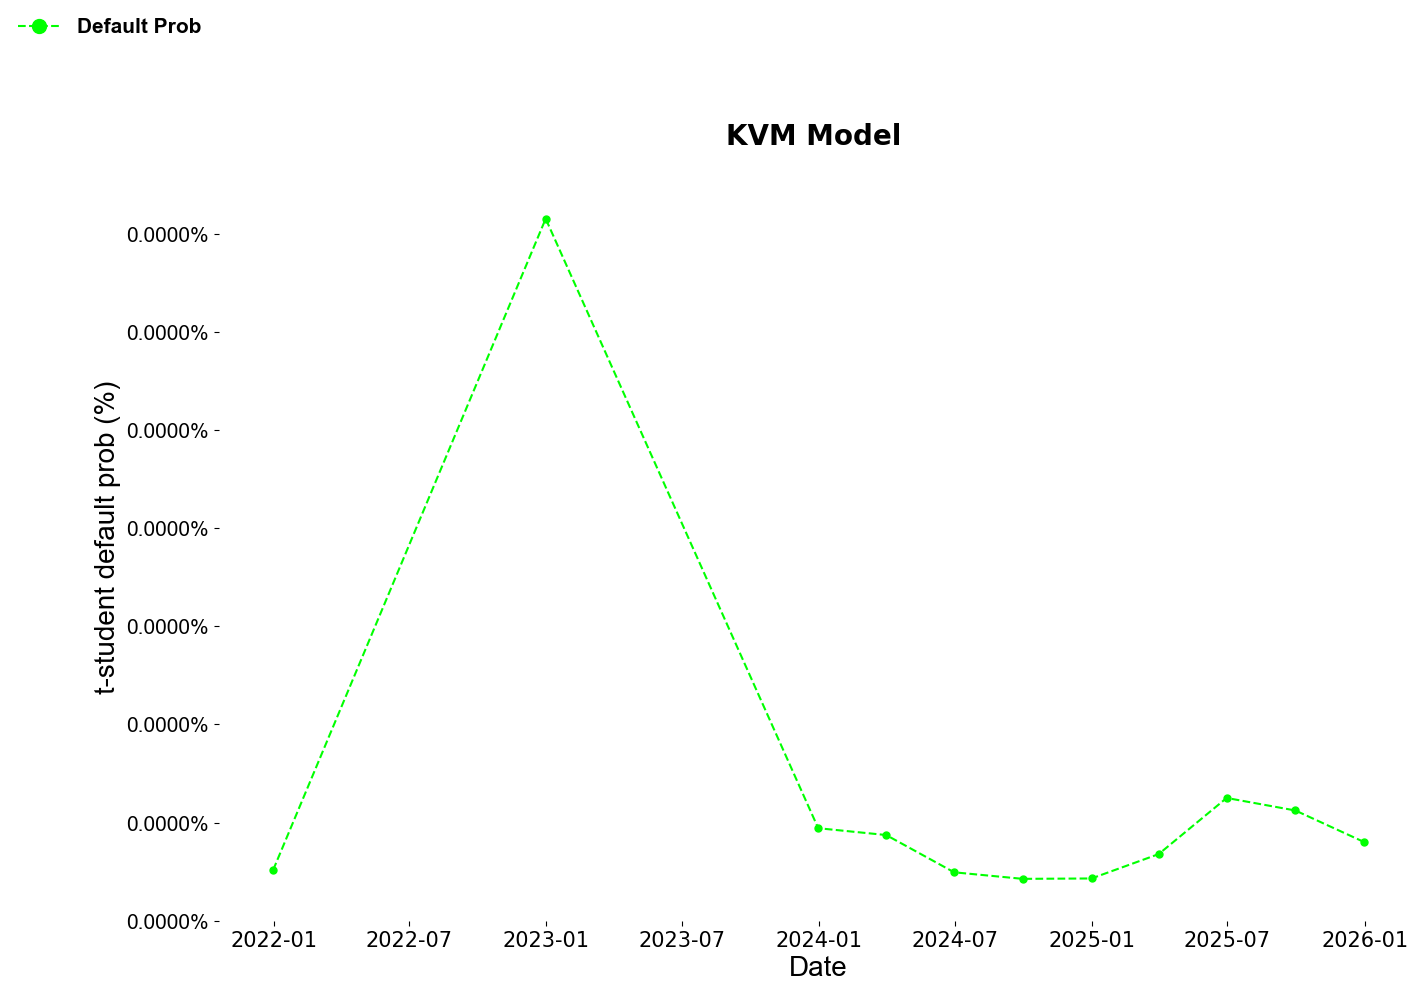

In [181]:
import matplotlib.font_manager as font_manager
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.dates as mdates
#Create chart
fig = plt.figure()
ax1 = plt.subplot(111,frameon=False)
font = font_manager.FontProperties(family='Arial',weight='bold', style='normal', size=15)

company_data.sort_values('date',ascending=True,inplace=True)

ax1.plot(company_data['date'],company_data['default_prob']*100,marker='o', linestyle='dashed',color='lime',label='Default Prob',markersize=5)
ax1.legend(frameon=False,prop=font,loc=1, bbox_to_anchor=(0.001, 1.2),ncol=10,markerscale=2)
ax1.set_xlabel('Date',fontname = "Arial", fontsize=20,color='black')
ax1.set_ylabel('t-student default prob (%)',fontname = "Arial", fontsize=20,color='black')
ax1.tick_params(axis='y', color = 'black', labelcolor='black')
ax1.yaxis.set_major_formatter(FormatStrFormatter('%2.4f%%'))
ax1.tick_params(axis="x", labelsize=15)
ax1.tick_params(axis="y", labelsize=15)

# Ajustar escala dinámicamente basada en los datos
min_val = company_data['default_prob'].min() * 100
max_val = company_data['default_prob'].max() * 100
margin = (max_val - min_val) * 0.1 if (max_val - min_val) > 0 else 0.1
ax1.set_ylim(max(0, min_val - margin), max_val + margin)

plt.title('KVM Model ',fontsize=20,weight="bold")
plt.yticks(fontname = "Arial",fontsize=15)
plt.subplots_adjust(wspace = 0.3,hspace = 0.8,bottom=0.1, right=2.0, top=1.7)
    
plt.show()

# Nutresa

In [182]:
# Lectura de datos XBRL - Nutresa Superfinanciera Liabilities

XBRL_PATH_NUTRESA = "Informes Nutresa"

FINANCIAL_STATEMENTS_NUTRESA = {
    "NUTRESA-20201231": ["0052589226_0066_000032_0000_000000_000000_C-C_2020-12-31.xbrl", "2021-01-01", "2020-10-01"],
    "NUTRESA-20211231": ["0052962043_0066_000032_0000_000000_000000_C-C_2021-12-31.xbrl", "2022-01-01", "2021-10-01"],
    "NUTRESA-20221231": ["0053312236_0066_000032_0000_000000_000000_C-C_2022-12-31.xbrl", "2023-01-01", "2022-10-01"],
    "NUTRESA-20231231": ["0053656074_0066_000032_0000_000000_000000_C-C_2023-12-31.xbrl", "2024-01-01", "2023-10-01"],
    "NUTRESA-20240331": ["0053714776_0066_000032_0000_000000_000000_C-I_2024-03-31.xbrl", "2024-04-01", "2024-01-01"],
    "NUTRESA-20240630": ["0053797199_0066_000032_0000_000000_000000_C-I_2024-06-30.xbrl", "2024-07-01", "2024-04-01"],
    "NUTRESA-20240930": ["0053887565_0066_000032_0000_000000_000000_C-I_2024-09-30.xbrl", "2024-10-01", "2024-07-01"],
    "NUTRESA-20241231": ["0053988109_0066_000032_0000_000000_000000_C-C_2024-12-31.xbrl", "2025-01-01", "2024-10-01"],
    "NUTRESA-20250331": ["0054071583_0066_000032_0000_000000_000000_C-I_2025-03-31.xbrl", "2025-04-01", "2025-01-01"],
    "NUTRESA-20250630": ["0054141770_0066_000032_0000_000000_000000_C-I_2025-06-30.xbrl", "2025-07-01", "2025-04-01"],
    "NUTRESA-20250930": ["0054231647_0066_000032_0000_000000_000000_C-I_2025-09-30.xbrl", "2025-10-01", "2025-07-01"],
    "NUTRESA-20251231": ["0054336110_0066_000032_0000_000000_000000_C-C_2025-12-31.xbrl", "2026-01-01", "2025-10-01"],
}

list_of_rows_nutresa = []

# Iterate through the dictionary - extract Equity, ProfitLoss, and Liabilities
for key in FINANCIAL_STATEMENTS_NUTRESA:
    
    COMPANY_FS = FINANCIAL_STATEMENTS_NUTRESA[key][0]
    XBRL_FILE = os.path.join(XBRL_PATH_NUTRESA, COMPANY_FS)
    
    # Import XBRL file
    xbrl = Cntlr.Cntlr().modelManager.load(XBRL_FILE)   
    
    # Extract all numeric facts into simple tuples
    facts_list = []
    for fact in xbrl.facts:
        if fact.isNumeric:
            facts_list.append((
                str(fact.concept.qname),
                fact.value,
                fact.context.startDatetime,
                fact.context.endDatetime
            ))
    
    # Create dataframe and assign column names directly
    if len(facts_list) > 0:
        factData = pd.DataFrame(facts_list, columns=['name', 'value', 'startDatetime', 'endDatetime'])
        
        # Convert value to numeric
        factData['value'] = pd.to_numeric(factData['value'], errors='coerce')
        
        period_end = pd.to_datetime(FINANCIAL_STATEMENTS_NUTRESA[key][1])
        period_start = pd.to_datetime(FINANCIAL_STATEMENTS_NUTRESA[key][2])
        
        # Extract EQUITY (instant period)
        Equity = factData[(factData['name']=="ifrs:Equity") & (factData['endDatetime']==period_end)]['value'].values[0]
        
        # Extract PROFITLOSS / NET INCOME (duration period)
        CurrentLiabilities = factData[(factData['name']=="ifrs:CurrentLiabilities") & (factData['endDatetime']==period_end)]['value'].values[0]
        
        # Extract LIABILITIES (instant period)
        Liabilities = factData[(factData['name']=="ifrs:Liabilities") & (factData['endDatetime']==period_end)]['value'].values[0]

        # Extract LIABILITIES (instant period)
        Shares = factData[(factData['name']=="ifrs:NumberOfSharesOutstanding") & (factData['endDatetime']==period_end)]['value'].values[0]
        
        # Create row dict and append to list
        row_dict = {
            'Date': FINANCIAL_STATEMENTS_NUTRESA[key][1],
            'Equity': Equity,
            'ProfitLoss': ProfitLoss,
            'Liabilities': Liabilities,
            'CurrentLiabilities': CurrentLiabilities,
            'SharesOutstanding': Shares
        }
        list_of_rows_nutresa.append(row_dict)
        print(f"✓ {key} extracted - Equity: {Equity:.0f}, CurrentLiabilities: {CurrentLiabilities:.0f}, Liabilities: {Liabilities:.0f},shares: {Shares:.0f}")

# Create final dataframe from list of dicts
data_summary_df_nutresa = pd.DataFrame(list_of_rows_nutresa)

✓ NUTRESA-20201231 extracted - Equity: 8257141744, CurrentLiabilities: 2440661120, Liabilities: 7280740775,shares: 460123458
✓ NUTRESA-20211231 extracted - Equity: 9042111934, CurrentLiabilities: 2628037175, Liabilities: 7914370766,shares: 457755869
✓ NUTRESA-20221231 extracted - Equity: 10804696453, CurrentLiabilities: 3808715417, Liabilities: 9952691427,shares: 457755869
✓ NUTRESA-20231231 extracted - Equity: 6444251335, CurrentLiabilities: 3703271713, Liabilities: 9244578686,shares: 457755869
✓ NUTRESA-20240331 extracted - Equity: 6517738701, CurrentLiabilities: 3319458865, Liabilities: 8859939077,shares: 0
✓ NUTRESA-20240630 extracted - Equity: 7031866908, CurrentLiabilities: 3391174330, Liabilities: 9294203371,shares: 0
✓ NUTRESA-20240930 extracted - Equity: 6849714676, CurrentLiabilities: 3647421268, Liabilities: 9938925195,shares: 0
✓ NUTRESA-20241231 extracted - Equity: 7118852385, CurrentLiabilities: 3701406666, Liabilities: 9823609331,shares: 457755869
✓ NUTRESA-20250331 extr

In [183]:
# Cargar precios históricos de Nutresa

precios_file = "Prices.xlsx"

# Read Nutresa prices
df_precios_nutresa = pd.read_excel(precios_file, sheet_name='Prices', engine='openpyxl')
df_precios_nutresa['Fecha'] = pd.to_datetime(df_precios_nutresa['Fecha'])

Nutresa = df_precios_nutresa[["Fecha","NUTRESA"]].copy()
Nutresa['return'] = Nutresa['NUTRESA']/Nutresa['NUTRESA'].shift(1) - 1
Nutresa['volatility'] = Nutresa['return'].rolling(window=252).std()*252**0.5
Nutresa.set_index('Fecha', inplace=True)

print("Precios de Nutresa cargados:")
print(Nutresa.tail())

Precios de Nutresa cargados:
            NUTRESA    return  volatility
Fecha                                    
2026-01-29   304500  0.000000    0.471750
2026-01-30   304500  0.000000    0.471750
2026-02-02   304500  0.000000    0.464005
2026-02-03   295000 -0.031199    0.458708
2026-02-04   319000  0.081356    0.461891


In [184]:
# Unificación de datos - Datos financieros + Precio coincidente

# Preparar datos
if 'Date' not in data_summary_df_nutresa.columns:
    data_summary_df_nutresa = data_summary_df_nutresa.reset_index()

data_summary_df_nutresa['Date'] = pd.to_datetime(data_summary_df_nutresa['Date'])
data_summary_df_nutresa.set_index('Date', inplace=True)

# Merge simple por fecha con tolerancia de 5 días hacia atrás
KMV_DATA_NUTRESA = pd.merge_asof(data_summary_df_nutresa, Nutresa, 
                                  left_index=True, 
                                  right_index=True, 
                                  tolerance=pd.Timedelta('5D'),
                                  direction='backward')

# Restaurar Date como columna y renombrar NUTRESA a Price
KMV_DATA_NUTRESA['Date'] = KMV_DATA_NUTRESA.index
KMV_DATA_NUTRESA = KMV_DATA_NUTRESA.reset_index(drop=True)
KMV_DATA_NUTRESA = KMV_DATA_NUTRESA.rename(columns={'NUTRESA': 'Price'})

print("Datos merged Nutresa:")
print(KMV_DATA_NUTRESA[['Date', 'Equity', 'Liabilities', "CurrentLiabilities", 'Price', 'volatility']])

Datos merged Nutresa:
         Date        Equity   Liabilities  CurrentLiabilities   Price  \
0  2021-01-01  8.257142e+09  7.280741e+09        2.440661e+09   24000   
1  2022-01-01  9.042112e+09  7.914371e+09        2.628037e+09   28640   
2  2023-01-01  1.080470e+10  9.952691e+09        3.808715e+09   44500   
3  2024-01-01  6.444251e+09  9.244579e+09        3.703272e+09   45000   
4  2024-04-01  6.517739e+09  8.859939e+09        3.319459e+09   46800   
5  2024-07-01  7.031867e+09  9.294203e+09        3.391174e+09   51800   
6  2024-10-01  6.849715e+09  9.938925e+09        3.647421e+09   69740   
7  2025-01-01  7.118852e+09  9.823609e+09        3.701407e+09   79000   
8  2025-04-01  7.209828e+09  1.835279e+10        1.164962e+10  123280   
9  2025-07-01  7.129058e+09  1.902920e+10        4.150212e+09  130000   
10 2025-10-01  6.625515e+09  2.066279e+10        4.374328e+09  174000   
11 2026-01-01  5.416712e+09  2.200261e+10        4.473368e+09  282000   

    volatility  
0     0.298

In [185]:
# Preparación de datos KMV - Nutresa

# Número de acciones en circulación de Nutresa
shares_outstanding_nutresa = 457755869 #Usamos este valor fijo porque en algunos xblr no viene el número de acciones
# Preparar datos para el iterador KMV
KMV_DATA_NUTRESA['Market_Cap'] = KMV_DATA_NUTRESA['Price'] * shares_outstanding_nutresa

KMV_DATA_NUTRESA['Liabilities_NonCurrent'] = KMV_DATA_NUTRESA['Liabilities'] - KMV_DATA_NUTRESA['CurrentLiabilities'] 
# Default Point = Pasivos Corrientes + 0.5 * Pasivos No Corrientes
KMV_DATA_NUTRESA['Default_Point'] = KMV_DATA_NUTRESA['CurrentLiabilities'] + 0.5 * KMV_DATA_NUTRESA['Liabilities_NonCurrent']

print("Datos preparados para KMV - Nutresa:")
print(KMV_DATA_NUTRESA[['Date', 'Market_Cap', 'Liabilities', 'Default_Point', 'volatility']])

Datos preparados para KMV - Nutresa:
         Date       Market_Cap   Liabilities  Default_Point  volatility
0  2021-01-01   10986140856000  7.280741e+09   4.860701e+09    0.298313
1  2022-01-01   13110128088160  7.914371e+09   5.271204e+09    0.320562
2  2023-01-01   20370136170500  9.952691e+09   6.880703e+09    0.872758
3  2024-01-01   20599014105000  9.244579e+09   6.473925e+09    0.320993
4  2024-04-01   21422974669200  8.859939e+09   6.089699e+09    0.228823
5  2024-07-01   23711754014200  9.294203e+09   6.342689e+09    0.458180
6  2024-10-01   31923894304060  9.938925e+09   6.793173e+09    0.469025
7  2025-01-01   36162713651000  9.823609e+09   6.762508e+09    0.488327
8  2025-04-01   56432143530320  1.835279e+10   1.500121e+10    0.536659
9  2025-07-01   59508262970000  1.902920e+10   1.158971e+10    0.373053
10 2025-10-01   79649521206000  2.066279e+10   1.251856e+10    0.371854
11 2026-01-01  129087155058000  2.200261e+10   1.323799e+10    0.484315


In [186]:
## Algoritmo iterativo para calcular Asset Value y Asset Volatility - Nutresa

# Algoritmo KMV - Iteración Merton Model

kmv_results_nutresa = pd.DataFrame()

for i in range(len(KMV_DATA_NUTRESA)):
    
    # Datos del período
    equity_vol = KMV_DATA_NUTRESA['volatility'].iloc[i]
    market_cap = KMV_DATA_NUTRESA['Market_Cap'].iloc[i]
    liabilities_current = KMV_DATA_NUTRESA['CurrentLiabilities'].iloc[i]
    liabilities_noncurrent = KMV_DATA_NUTRESA['Liabilities_NonCurrent'].iloc[i]
    date = KMV_DATA_NUTRESA['Date'].iloc[i]
    

    # Inicialización
    initial_assets = market_cap + liabilities_current + liabilities_noncurrent
    assets = initial_assets
    liabilities = liabilities_current + liabilities_noncurrent
    dp = liabilities_current + 0.5 * liabilities_noncurrent  # Default Point
    initial_asset_vol = equity_vol
    asset_vol = initial_asset_vol
    equity = market_cap
    
    # Parámetros del modelo
    r = 0.05  # Risk-free rate
    T = 1     # Time horizon (1 year)
    epsilon = 1  # Inicializar convergencia
    iterations = 0
    max_iterations = 1000
    
    # Ecuaciones Merton Model
    def function1(x):
        d1 = (np.log(x/dp) + (r + 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
        d2 = (np.log(x/dp) + (r - 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
        return x - (market_cap + np.exp(-r*T)*dp*norm.cdf(d2))
    
    def function2(x):
        d1 = (np.log(assets/dp) + (r + 0.5*x**2)*T) / (x*T**0.5)
        return equity_vol - norm.cdf(d1) * (assets/market_cap) * x
    
    # Iteración hasta convergencia
    while epsilon > 0.00001 and iterations < max_iterations:
        # Resolver para asset_vol
        try:
            sol2 = root(function2, asset_vol, method='hybr')
            asset_vol_new = sol2.x[0]
        except:
            asset_vol_new = asset_vol
        
        # Resolver para assets
        try:
            sol1 = root(function1, assets, method='hybr')
            assets_new = sol1.x[0]
        except:
            assets_new = assets
        
        epsilon = abs(asset_vol_new - asset_vol)
        asset_vol = asset_vol_new
        assets = assets_new
        iterations += 1
    
    # Calcular d1 y d2 finales
    d1 = (np.log(assets/dp) + (r + 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
    d2 = (np.log(assets/dp) + (r - 0.5*asset_vol**2)*T) / (asset_vol*T**0.5)
    
    # Probabilidad de default usando t-student
    default_prob = t_dist.cdf(-d2, 5)  # t-student con 5 grados de libertad
    
    # Almacenar resultados
    result_row = {
        'Date': date,
        'Assets': assets,
        'Liabilities': liabilities,
        'Liabilities_Current': liabilities_current,
        'Liabilities_NonCurrent': liabilities_noncurrent,
        'Default_Point': dp,
        'Market_Cap': market_cap,
        'Equity_Vol': equity_vol,
        'Asset_Vol': asset_vol,
        'd1': d1,
        'd2': d2,
        'Default_Prob': default_prob,
        'Distance_to_Default': d2,
        'Iterations': iterations
    }
    
    kmv_results_nutresa = pd.concat([kmv_results_nutresa, pd.DataFrame([result_row])], ignore_index=True)
    print(f"  ✓ Asset Vol: {asset_vol:.4f} | d2: {d2:.4f} | Default Prob: {default_prob*100:.4f}%")

print("\n" + "="*80)
print("✓ ITERACIÓN COMPLETADA - NUTRESA")
print("="*80)
print(f"\nResultados: {len(kmv_results_nutresa)} períodos calculados")
print("\nPrimeras filas:")
print(kmv_results_nutresa[['Date', 'Assets', 'Asset_Vol', 'd2', 'Default_Prob']].head())

  ✓ Asset Vol: 0.2982 | d2: 25.9205 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.3204 | d2: 24.3975 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.8725 | d2: 8.7828 | Default Prob: 0.0159%
  ✓ Asset Vol: 0.3209 | d2: 25.1297 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.2288 | d2: 35.8004 | Default Prob: 0.0000%
  ✓ Asset Vol: 0.4581 | d2: 17.8398 | Default Prob: 0.0005%
  ✓ Asset Vol: 0.4689 | d2: 17.9034 | Default Prob: 0.0005%
  ✓ Asset Vol: 0.4882 | d2: 17.4410 | Default Prob: 0.0006%
  ✓ Asset Vol: 0.5365 | d2: 15.1699 | Default Prob: 0.0011%
  ✓ Asset Vol: 0.3730 | d2: 22.8546 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.3718 | d2: 23.5052 | Default Prob: 0.0001%
  ✓ Asset Vol: 0.4843 | d2: 18.8284 | Default Prob: 0.0004%

✓ ITERACIÓN COMPLETADA - NUTRESA

Resultados: 12 períodos calculados

Primeras filas:
        Date        Assets  Asset_Vol         d2  Default_Prob
0 2021-01-01  1.099076e+13   0.298187  25.920539  7.982757e-07
1 2022-01-01  1.311514e+13   0.320439  24.397515  1.078351e-06
2 202

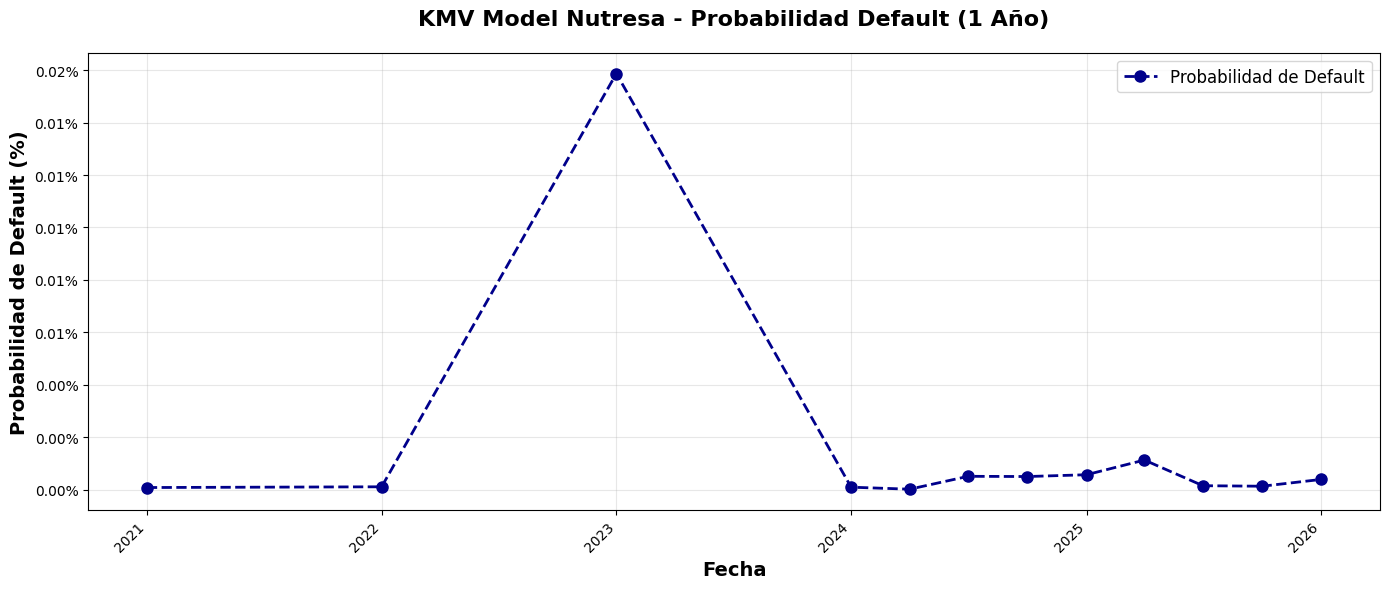

In [187]:
## Visualización de Resultados - Nutresa

# Gráfico de Probabilidad de Default
fig, ax = plt.subplots(figsize=(14, 6))

kmv_results_nutresa_sorted = kmv_results_nutresa.sort_values('Date')

ax.plot(kmv_results_nutresa_sorted['Date'], 
        kmv_results_nutresa_sorted['Default_Prob']*100, 
        marker='o', 
        linestyle='dashed', 
        color='darkblue', 
        label='Probabilidad de Default', 
        markersize=8,
        linewidth=2)

ax.set_xlabel('Fecha', fontsize=14, fontweight='bold')
ax.set_ylabel('Probabilidad de Default (%)', fontsize=14, fontweight='bold')
ax.set_title('KMV Model Nutresa - Probabilidad Default (1 Año)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}%'))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()